In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
plt.style.use('ggplot')  # 更改绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei']

Text(0.5, 1.0, '每月的消费人数')

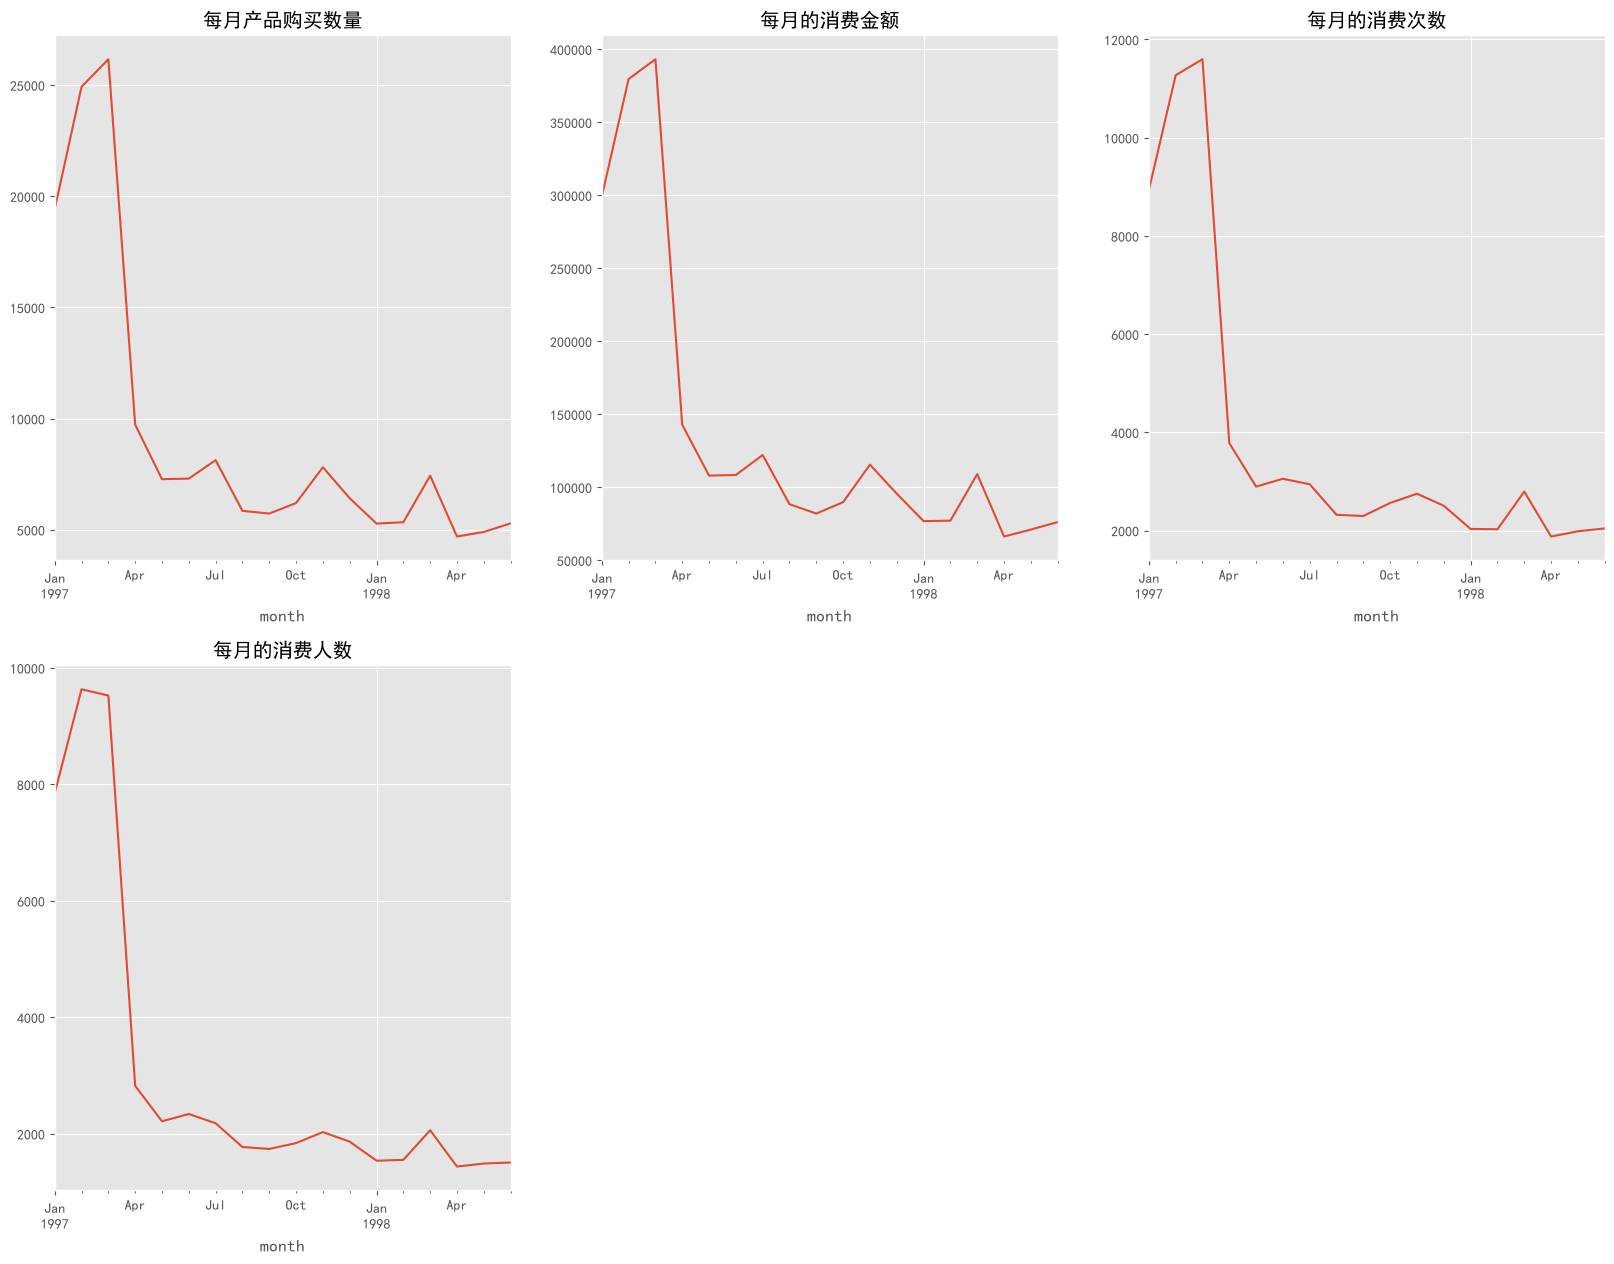

In [24]:
# 导入数据
columns = ['user_id', 'order_dt', 'order_products', 'order_amount']
# sep=r'\s+'：匹配任意空格字符
df = pd.read_csv('../data/ecommerce_transactions.txt', header=None, names=columns, sep=r'\s+')
# 处理日期格式（order_dt）
df['order_date'] = pd.to_datetime(df['order_dt'],
                                  format='%Y%m%d')  # %Y：4位数年份1949 %y：两位数年份49 %m：两位数月份 %d：两位数月份 %h：两位数小时 %M：两位数分钟 %s：两位数秒
'''
df ['month'] 字段说明
用途：按月聚合分组的标记字段
输入源：order_date（datetime 日期列）
运算链路：datetime 日期 → 月度周期 Period → 转回 datetime（当月第一天）
输出类型：datetime64 [us]，可正常使用.dt、groupby、绘图筛选
等价简写：df ['month'] = df ['order_date'].dt.floor ('MS')
'''
df['month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()
# 按照月份分析每个用户的消费金额，次数，消费人数
plt.figure(figsize=(20, 15))  # 单位：英寸
plt.subplot(2, 3, 1)
df.groupby(by='month')['order_products'].sum().plot()
plt.title('每月产品购买数量')
plt.subplot(2, 3, 2)
df.groupby(by='month')['order_amount'].sum().plot()
plt.title('每月的消费金额')
plt.subplot(2, 3, 3)
df.groupby(by='month')['user_id'].count().plot()
plt.title('每月的消费次数')
plt.subplot(2, 3, 4)
df.groupby(by='month')['user_id'].nunique().plot()
plt.title('每月的消费人数')